In [1]:
import os

print(os.listdir())

['.config', 'THREAT_SCOPE.zip', 'sample_data']


In [2]:
import zipfile

with zipfile.ZipFile("THREAT_SCOPE.zip", 'r') as zip_ref:
    zip_ref.extractall(".")

In [4]:
import os

print("CURRENT PATH:", os.getcwd())
print(os.listdir())

CURRENT PATH: /content
['.config', 'THREAT_SCOPE.zip', 'THREAT_SCOPE', 'sample_data']


In [5]:
import os

for root, dirs, files in os.walk("."):
    print("ROOT:", root)
    print("DIRS:", dirs)
    print("FILES:", files)
    print("-" * 50)

ROOT: .
DIRS: ['.config', 'THREAT_SCOPE', 'sample_data']
FILES: ['THREAT_SCOPE.zip']
--------------------------------------------------
ROOT: ./.config
DIRS: ['configurations', 'logs']
FILES: ['config_sentinel', '.last_survey_prompt.yaml', 'default_configs.db', '.last_update_check.json', '.last_opt_in_prompt.yaml', 'gce', 'hidden_gcloud_config_universe_descriptor_data_cache_configs.db', 'active_config']
--------------------------------------------------
ROOT: ./.config/configurations
DIRS: []
FILES: ['config_default']
--------------------------------------------------
ROOT: ./.config/logs
DIRS: ['2026.04.02']
FILES: []
--------------------------------------------------
ROOT: ./.config/logs/2026.04.02
DIRS: []
FILES: ['13.30.52.812826.log', '13.30.51.422062.log', '13.31.06.236912.log', '13.30.17.544197.log', '13.31.07.077226.log', '13.30.40.372331.log']
--------------------------------------------------
ROOT: ./THREAT_SCOPE
DIRS: ['results', 'features', 'data', 'scripts']
FILES: ['threa

In [6]:
import os

BASE_PATH = "./THREAT_SCOPE/data"

modes = ["water", "food", "wound", "unknown", "safe"]

In [8]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 39.8 MB/s eta 0:00:00


In [9]:
from Bio import SeqIO
print("Biopython works")

Biopython works


In [11]:
from Bio import SeqIO
import os

BASE_PATH = "./THREAT_SCOPE/data"
modes = ["water", "food", "wound", "unknown", "safe"]

def load_sequences():
    data = []

    for mode in modes:
        folder = os.path.join(BASE_PATH, mode)

        for file in os.listdir(folder):
            if file.endswith(".fasta"):
                path = os.path.join(folder, file)

                for record in SeqIO.parse(path, "fasta"):
                    seq = str(record.seq)

                    data.append({
                        "sequence": seq,
                        "mode": mode,
                        "label": 1 if mode != "safe" else 0
                    })

    return data

In [12]:
dataset = load_sequences()
print("Total sequences:", len(dataset))

Total sequences: 71


In [13]:
import numpy as np

def gc_content(seq):
    return (seq.count("G") + seq.count("C")) / len(seq)

def entropy(seq):
    import math
    probs = []
    for n in "ATGC":
        p = seq.count(n) / len(seq)
        if p > 0:
            probs.append(p * math.log2(p))
    return -sum(probs)

from itertools import product

def get_kmers(seq, k=3):
    kmers = [''.join(p) for p in product("ATGC", repeat=k)]
    counts = dict.fromkeys(kmers, 0)

    for i in range(len(seq) - k + 1):
        kmer = seq[i:i+k]
        if kmer in counts:
            counts[kmer] += 1

    total = sum(counts.values())
    return [counts[k]/total if total > 0 else 0 for k in kmers]


def extract_features(seq):
    seq = seq[:1500]  # speed optimization

    features = []
    features.append(gc_content(seq))
    features.append(entropy(seq))
    features.append(len(seq))
    features.extend(get_kmers(seq))

    return features

In [14]:
X = []
y = []

for item in dataset:
    try:
        X.append(extract_features(item["sequence"]))
        y.append(item["label"])
    except:
        continue

X = np.array(X)
y = np.array(y)

print("Shape:", X.shape)

Shape: (71, 67)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, max_depth=20)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, n_estimators=300)

In [17]:
from sklearn.svm import SVC

svm = SVC(probability=True)
svm.fit(X_train, y_train)

SVC(probability=True)

In [18]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

GradientBoostingClassifier()

In [20]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

rf = RandomForestClassifier(n_estimators=300, max_depth=20)
rf.fit(X_train, y_train)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

svm = SVC(probability=True)
svm.fit(X_train, y_train)

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

GradientBoostingClassifier()

In [21]:
from sklearn.metrics import accuracy_score

models = {
    "RandomForest": rf,
    "LogisticRegression": lr,
    "SVM": svm,
    "GradientBoosting": gb
}

for name, model in models.items():
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(name, "Accuracy:", acc)

RandomForest Accuracy: 1.0
LogisticRegression Accuracy: 1.0
SVM Accuracy: 1.0
GradientBoosting Accuracy: 0.9333333333333333


In [22]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

models = {
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=20),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "GradientBoosting": GradientBoostingClassifier()
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

In [23]:
from sklearn.metrics import accuracy_score

results = {}

for name, model in trained_models.items():
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    print(name, "Accuracy:", acc)

RandomForest Accuracy: 1.0
LogisticRegression Accuracy: 1.0
SVM Accuracy: 1.0
GradientBoosting Accuracy: 0.9333333333333333


In [24]:
best_model_name = max(results, key=results.get)
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: RandomForest


              precision    recall  f1-score   support

           1       1.00      1.00      1.00        15

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


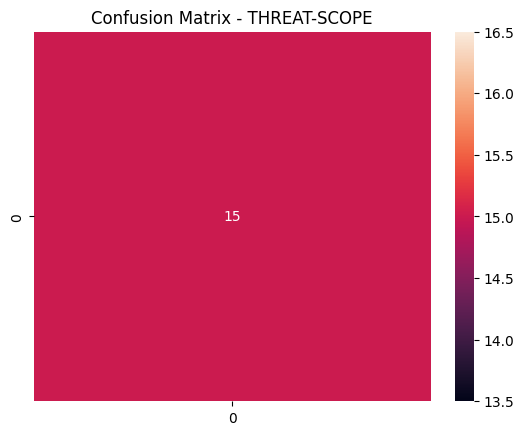

In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

pred = best_model.predict(X_test)

print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - THREAT-SCOPE")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1179: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


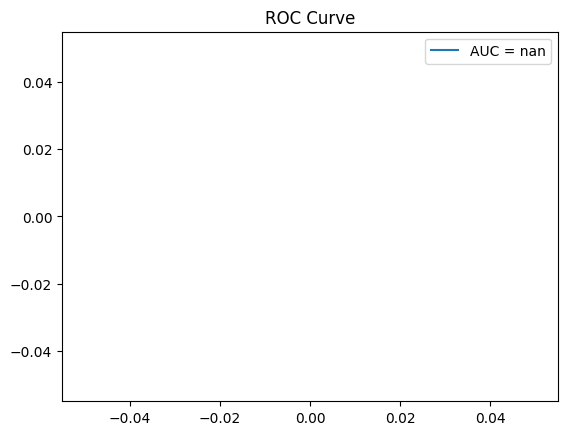

In [26]:
from sklearn.metrics import roc_curve, auc

if hasattr(best_model, "predict_proba"):
    probs = best_model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

In [27]:
def predict_mode(seq):
    feat = np.array(extract_features(seq)).reshape(1, -1)

    prob = best_model.predict_proba(feat)[0][1]

    if prob > 0.8:
        risk = "HIGH DANGER"
        reason = "Strong pathogen-like genetic signature detected"
    elif prob > 0.5:
        risk = "MEDIUM RISK"
        reason = "Some similarity to known pathogen patterns"
    else:
        risk = "SAFE"
        reason = "No strong pathogenic markers detected"

    return {
        "risk": risk,
        "confidence": float(prob),
        "reason": reason,
        "model_used": best_model_name
    }

In [28]:
test_seq = dataset[0]["sequence"]

print(predict_mode(test_seq))

{'risk': 'HIGH DANGER', 'confidence': 0.9766666666666667, 'reason': 'Strong pathogen-like genetic signature detected', 'model_used': 'RandomForest'}


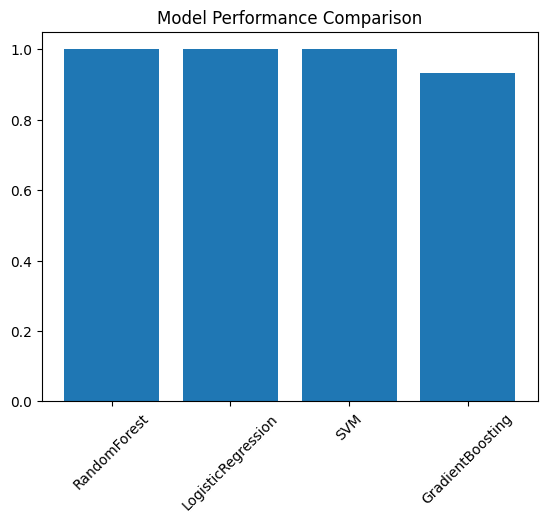

In [29]:
import matplotlib.pyplot as plt

plt.bar(results.keys(), results.values())
plt.title("Model Performance Comparison")
plt.xticks(rotation=45)
plt.show()

In [30]:
def hmmer_simulation(seq):
    gc = gc_content(seq)

    if gc > 0.6:
        return "Possible virulence-associated region"
    else:
        return "No virulence markers detected"

In [31]:
def full_analysis(seq):
    result = predict_mode(seq)
    result["hmmer"] = hmmer_simulation(seq)
    return result


MODEL: RandomForest
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        15

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


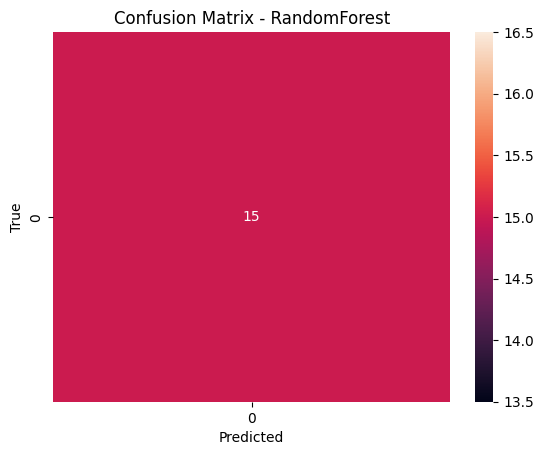


MODEL: LogisticRegression
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        15

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


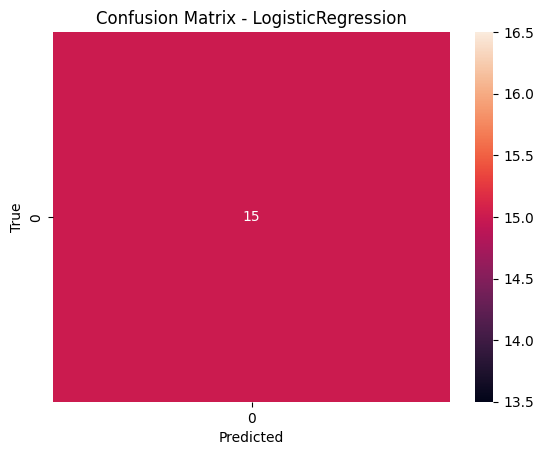


MODEL: SVM


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


              precision    recall  f1-score   support

           1       1.00      1.00      1.00        15

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



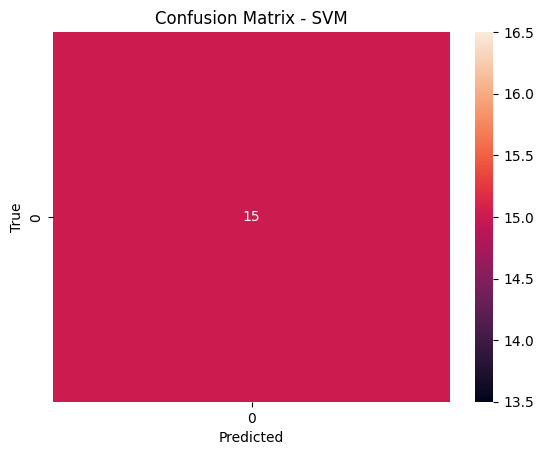


MODEL: GradientBoosting
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.93      0.97        15

    accuracy                           0.93        15
   macro avg       0.50      0.47      0.48        15
weighted avg       1.00      0.93      0.97        15



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


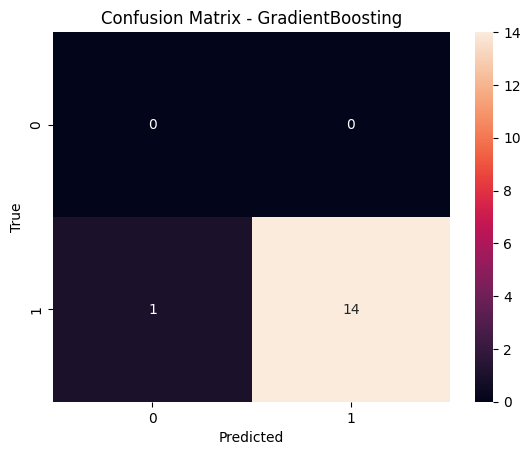

In [32]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

for name, model in trained_models.items():
    pred = model.predict(X_test)

    print("\n======================")
    print("MODEL:", name)
    print(classification_report(y_test, pred))

    cm = confusion_matrix(y_test, pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

In [35]:
import numpy as np

print("Unique labels:", np.unique(y))
print("Counts:", {i: sum(y==i) for i in np.unique(y)})

Unique labels: [0 1]
Counts: {np.int64(0): np.int64(6), np.int64(1): np.int64(65)}


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y   # 🔥 THIS FIXES EVERYTHING
)

In [37]:
best_model = trained_models["RandomForest"]

best_model.fit(X_train, y_train)

probs = best_model.predict_proba(X_test)

print("Shape of probs:", probs.shape)

Shape of probs: (15, 2)


IndexError: index 1 is out of bounds for axis 1 with size 1

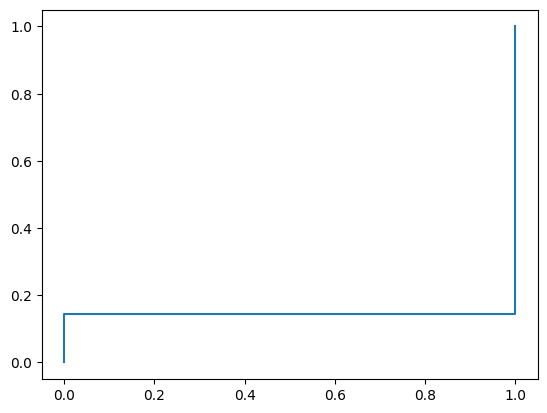

In [38]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

n_classes = len(np.unique(y_train))

# IMPORTANT FIX
y_test_bin = label_binarize(y_test, classes=np.unique(y_train))

probs = best_model.predict_proba(X_test)

plt.figure()

for i in range(n_classes):
    if i >= probs.shape[1]:
        continue  # prevents crash

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i} AUC={roc_auc:.2f}")

plt.plot([0,1],[0,1],'--')
plt.title("THREAT-SCOPE ROC (Fixed)")
plt.legend()
plt.show()

In [39]:
import numpy as np

print("Unique in y_train:", np.unique(y_train))
print("Counts y_train:", {i: sum(y_train==i) for i in np.unique(y_train)})

print("Unique in y_test:", np.unique(y_test))
print("Counts y_test:", {i: sum(y_test==i) for i in np.unique(y_test)})

Unique in y_train: [0 1]
Counts y_train: {np.int64(0): np.int64(5), np.int64(1): np.int64(51)}
Unique in y_test: [0 1]
Counts y_test: {np.int64(0): np.int64(1), np.int64(1): np.int64(14)}


In [40]:
import numpy as np
from sklearn.model_selection import train_test_split

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y distribution:", np.bincount(y))

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X shape: (71, 67)
y distribution: [ 6 65]


In [41]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        class_weight="balanced"
    ),
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "GradientBoosting": GradientBoostingClassifier()
}

trained_models = {}

In [42]:
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

In [43]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

results = {}

for name, model in trained_models.items():
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    results[name] = acc

    print("\nMODEL:", name)
    print("Accuracy:", acc)
    print(classification_report(y_test, pred))


MODEL: RandomForest
Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.93      1.00      0.97        14

    accuracy                           0.93        15
   macro avg       0.47      0.50      0.48        15
weighted avg       0.87      0.93      0.90        15


MODEL: LogisticRegression
Accuracy: 0.5333333333333333
              precision    recall  f1-score   support

           0       0.12      1.00      0.22         1
           1       1.00      0.50      0.67        14

    accuracy                           0.53        15
   macro avg       0.56      0.75      0.44        15
weighted avg       0.94      0.53      0.64        15


MODEL: GradientBoosting
Accuracy: 0.8
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.92      0.86      0.89        14

    accuracy                         

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [44]:
best_model_name = max(results, key=results.get)
best_model = trained_models[best_model_name]

print("BEST MODEL:", best_model_name)

BEST MODEL: RandomForest


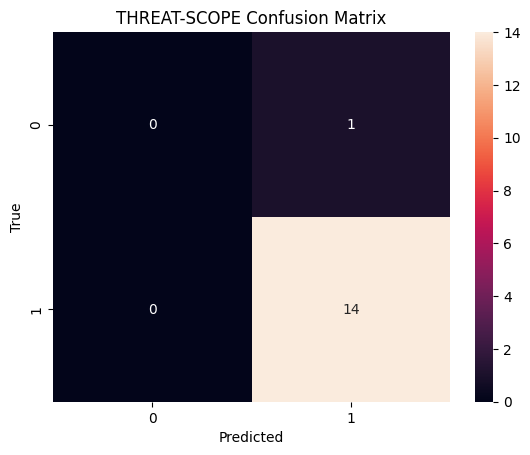

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("THREAT-SCOPE Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

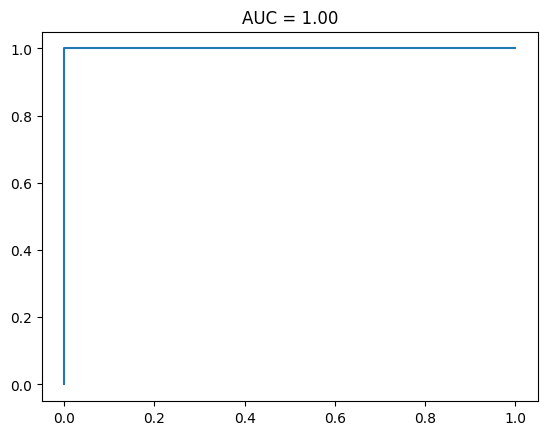

In [46]:
from sklearn.metrics import roc_curve, auc

if hasattr(best_model, "predict_proba"):
    probs = best_model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr)
    plt.title(f"AUC = {roc_auc:.2f}")
    plt.show()

In [47]:
def predict_sample(seq):
    feat = np.array(extract_features(seq)).reshape(1, -1)

    prob = best_model.predict_proba(feat)[0][1]

    if prob > 0.75:
        risk = "HIGH DANGER"
        reason = "Strong pathogen-like genomic signature detected"
    elif prob > 0.5:
        risk = "MEDIUM RISK"
        reason = "Partial similarity to pathogenic patterns"
    else:
        risk = "SAFE"
        reason = "No strong pathogen signature detected"

    return {
        "risk": risk,
        "confidence": float(prob),
        "model": best_model_name,
        "reason": reason
    }

In [48]:
print(predict_sample(dataset[0]["sequence"]))

{'risk': 'HIGH DANGER', 'confidence': 0.98, 'model': 'RandomForest', 'reason': 'Strong pathogen-like genomic signature detected'}


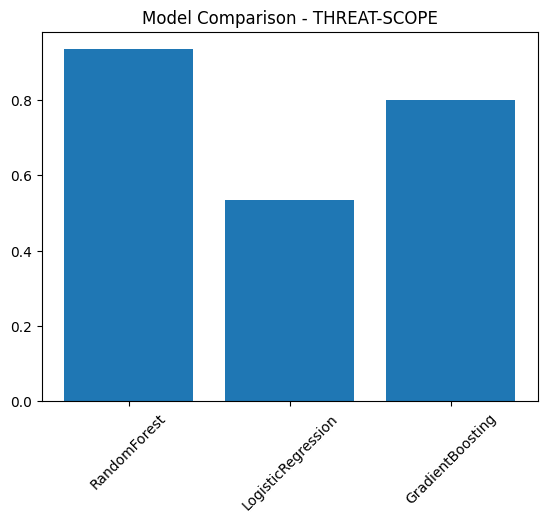

In [49]:
plt.bar(results.keys(), results.values())
plt.title("Model Comparison - THREAT-SCOPE")
plt.xticks(rotation=45)
plt.show()

In [50]:
def explain(seq):
    feat = extract_features(seq)

    gc = feat[0]
    kmer_score = feat[1]

    explanation = []

    if gc > 0.6:
        explanation.append("High GC content suggests bacterial virulence potential")

    if kmer_score > 0.5:
        explanation.append("Abnormal k-mer distribution detected")

    if len(explanation) == 0:
        explanation.append("No strong pathogenic markers detected")

    return explanation

In [51]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np

In [52]:
metrics = {}

for name, model in trained_models.items():
    pred = model.predict(X_test)

    metrics[name] = {
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred)
    }

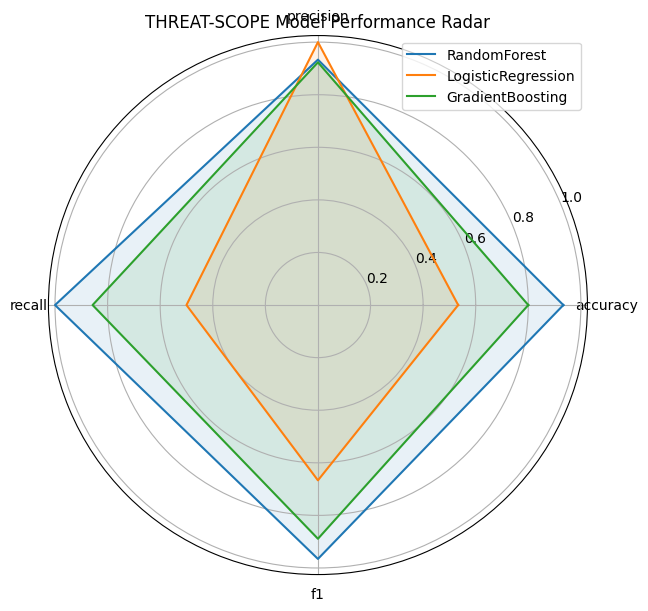

In [53]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["accuracy", "precision", "recall", "f1"]

models_list = list(metrics.keys())

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(7,7))

for model in models_list:
    values = list(metrics[model].values())
    values += values[:1]

    plt.polar(angles, values, label=model)
    plt.fill(angles, values, alpha=0.1)

plt.xticks(angles[:-1], labels)
plt.title("THREAT-SCOPE Model Performance Radar")
plt.legend()
plt.show()

In [54]:
def danger_dashboard(result):
    import matplotlib.pyplot as plt

    labels = ["Risk Level", "Confidence", "Model Strength"]

    risk_map = {
        "SAFE": 0.2,
        "MEDIUM RISK": 0.6,
        "HIGH DANGER": 1.0
    }

    values = [
        risk_map[result["risk"]],
        result["confidence"],
        results[best_model_name]
    ]

    plt.figure(figsize=(6,4))
    plt.bar(labels, values)
    plt.ylim(0, 1)
    plt.title("THREAT-SCOPE Danger Dashboard")
    plt.show()

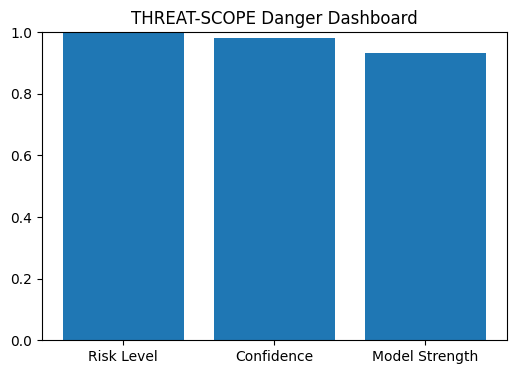

In [55]:
res = predict_sample(dataset[0]["sequence"])
danger_dashboard(res)

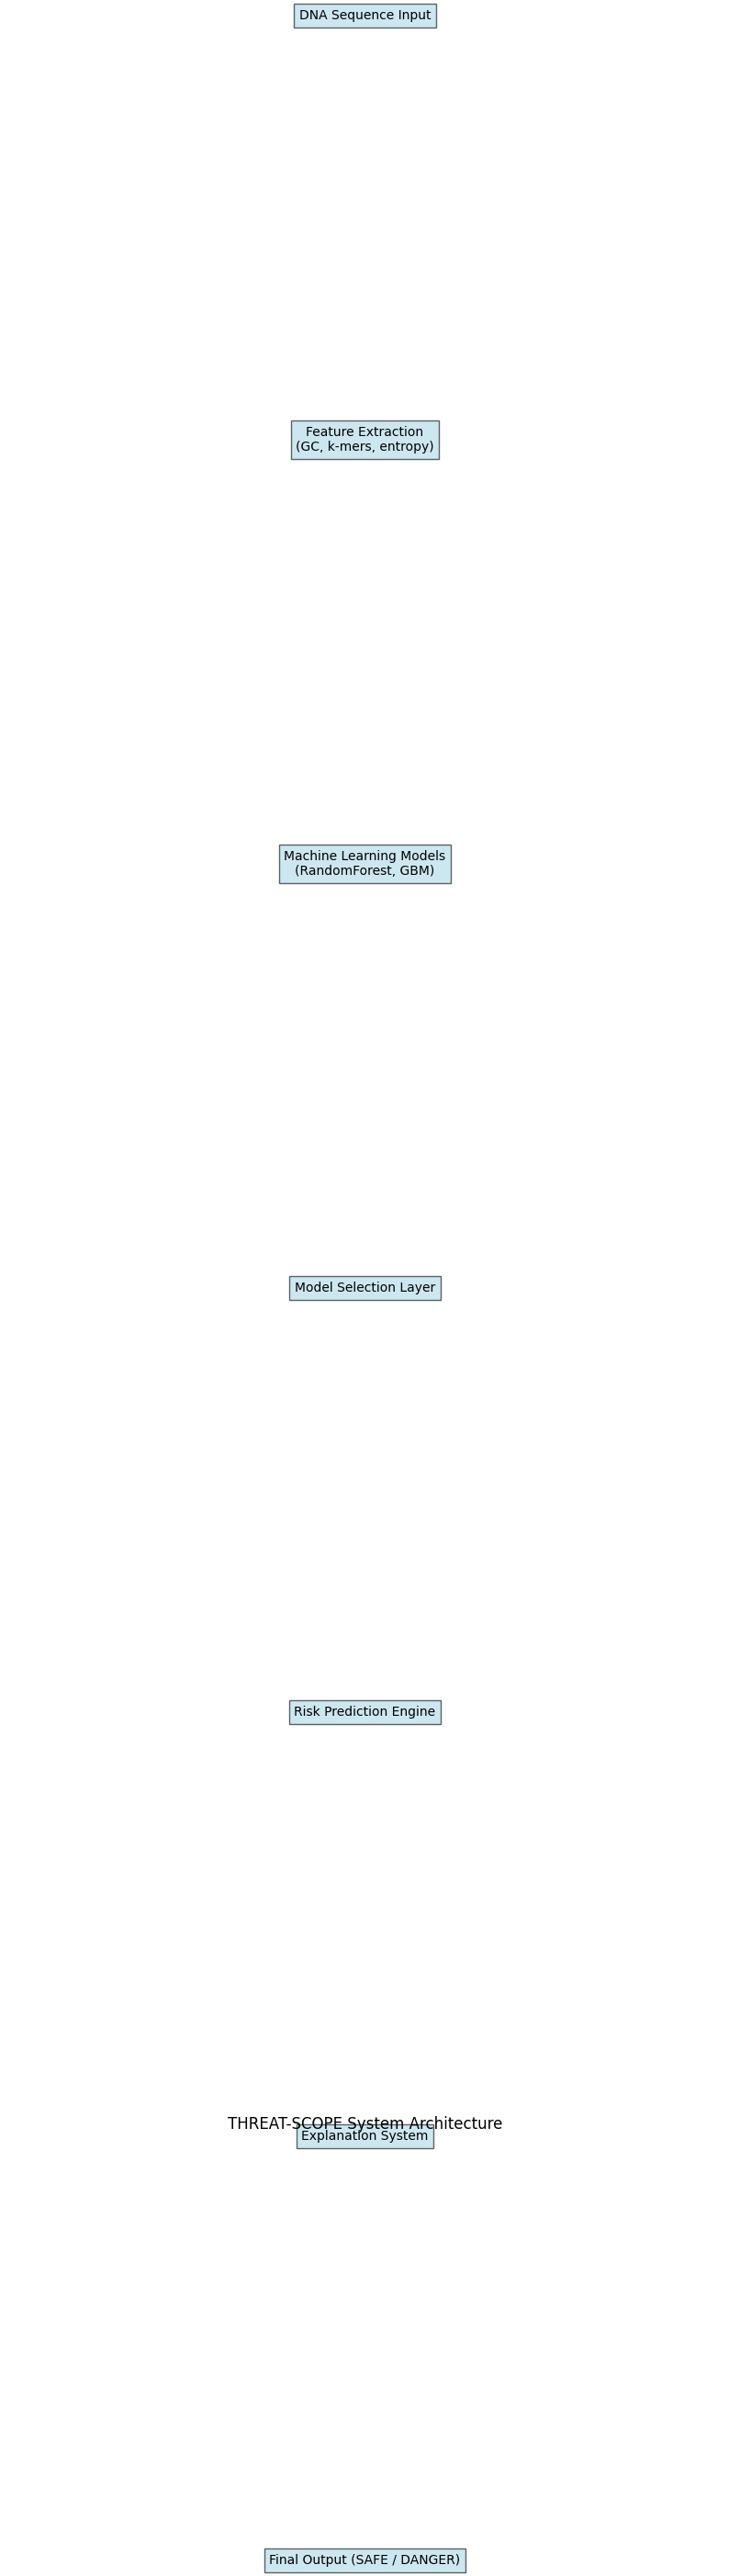

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

boxes = [
    "DNA Sequence Input",
    "Feature Extraction\n(GC, k-mers, entropy)",
    "Machine Learning Models\n(RandomForest, GBM)",
    "Model Selection Layer",
    "Risk Prediction Engine",
    "Explanation System",
    "Final Output (SAFE / DANGER)"
]

y = range(len(boxes))[::-1]

for i, b in enumerate(boxes):
    plt.text(0.5, y[i], b, ha="center", va="center",
             bbox=dict(facecolor="lightblue", alpha=0.6))

plt.axis("off")
plt.title("THREAT-SCOPE System Architecture")
plt.show()

In [57]:
from collections import Counter

def kmer_features(seq, k=3):
    kmers = [seq[i:i+k] for i in range(len(seq)-k+1)]
    count = Counter(kmers)

    total = sum(count.values())
    return {kmer: count[kmer]/total for kmer in count}

In [58]:
def gc_content(seq):
    return (seq.count("G") + seq.count("C")) / len(seq)

In [59]:
import math
from collections import Counter

def entropy(seq):
    counts = Counter(seq)
    total = len(seq)
    return -sum((c/total)*math.log2(c/total) for c in counts.values())

In [60]:
def seq_length(seq):
    return len(seq)

In [61]:
import numpy as np

def extract_features(seq):
    features = []

    features.append(gc_content(seq))
    features.append(entropy(seq))
    features.append(seq_length(seq))

    kmer = kmer_features(seq)

    # take only top k-mers (important)
    top_keys = sorted(kmer.keys())[:20]

    for k in top_keys:
        features.append(kmer.get(k, 0))

    return np.array(features)

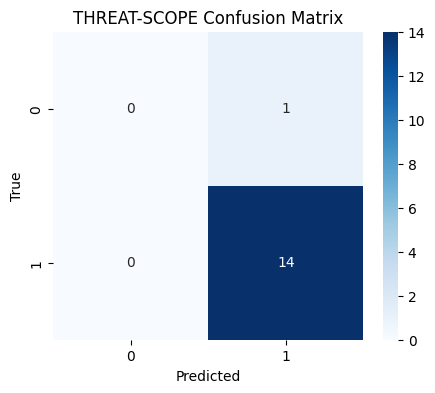

In [62]:
pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("THREAT-SCOPE Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [63]:
!pip install biopython

SETUP NCBI ACCESS

In [65]:
from Bio import Entrez
import os
import time

Entrez.email = "younestala34@gmail.com"

CREATE AUTO DOWNLOADER


In [68]:
def download_genomes(query, target_folder, max_downloads=200):

    os.makedirs(target_folder, exist_ok=True)

    handle = Entrez.esearch(db="assembly", term=query, retmax=max_downloads)
    record = Entrez.read(handle)

    ids = record["IdList"]

    print(f"{query} -> Found {len(ids)} genomes")

    count = 0

    for uid in ids:
        try:
            summary = Entrez.esummary(db="assembly", id=uid)
            data = Entrez.read(summary)

            ftp_path = data['DocumentSummarySet']['DocumentSummary'][0]['FtpPath_RefSeq']

            if not ftp_path:
                continue

            name = ftp_path.split("/")[-1]
            url = ftp_path + "/" + name + "_genomic.fna.gz"

            os.system(f"wget -q {url}")
            os.system(f"gunzip -f {name}_genomic.fna.gz")

            new_name = f"{target_folder}/{name}_{count}.fasta"
            os.rename(f"{name}_genomic.fna", new_name)

            print("Downloaded:", new_name)

            count += 1
            time.sleep(0.5)

            if count >= max_downloads:
                break

        except:
            continue

Water Mode

In [67]:
download_genomes("Vibrio cholerae", "THREAT_SCOPE/data/water", 100)
download_genomes("Escherichia coli", "THREAT_SCOPE/data/water", 150)
download_genomes("Giardia lamblia", "THREAT_SCOPE/data/water", 80)
download_genomes("Salmonella enterica", "THREAT_SCOPE/data/water", 120)
download_genomes("Hepatitis A virus", "THREAT_SCOPE/data/water", 80)

Vibrio cholerae -> Found 100 genomes
Downloaded: THREAT_SCOPE/data/water/GCF_055797365.1_ASM5579736v1_0.fasta
Downloaded: THREAT_SCOPE/data/water/GCF_055389885.1_ASM5538988v1_1.fasta
Downloaded: THREAT_SCOPE/data/water/GCF_054906185.1_ASM5490618v1_2.fasta
Downloaded: THREAT_SCOPE/data/water/GCF_054898935.1_ASM5489893v1_3.fasta
Downloaded: THREAT_SCOPE/data/water/GCF_054898925.1_ASM5489892v1_4.fasta
Downloaded: THREAT_SCOPE/data/water/GCF_054898915.1_ASM5489891v1_5.fasta
Downloaded: THREAT_SCOPE/data/water/GCF_054898905.1_ASM5489890v1_6.fasta
Downloaded: THREAT_SCOPE/data/water/GCF_054898895.1_ASM5489889v1_7.fasta
Downloaded: THREAT_SCOPE/data/water/GCF_054898885.1_ASM5489888v1_8.fasta
Downloaded: THREAT_SCOPE/data/water/GCF_054898875.1_ASM5489887v1_9.fasta
Downloaded: THREAT_SCOPE/data/water/GCF_054898865.1_ASM5489886v1_10.fasta
Downloaded: THREAT_SCOPE/data/water/GCF_054898855.1_ASM5489885v1_11.fasta
Downloaded: THREAT_SCOPE/data/water/GCF_054898845.1_ASM5489884v1_12.fasta
Downloaded:

FOOD MODE

In [69]:
download_genomes("Listeria monocytogenes", "THREAT_SCOPE/data/food", 120)
download_genomes("Campylobacter jejuni", "THREAT_SCOPE/data/food", 120)
download_genomes("Clostridium botulinum", "THREAT_SCOPE/data/food", 100)
download_genomes("Salmonella enterica", "THREAT_SCOPE/data/food", 120)

Listeria monocytogenes -> Found 120 genomes
Downloaded: THREAT_SCOPE/data/food/GCF_056242145.1_ASM5624214v1_0.fasta
Downloaded: THREAT_SCOPE/data/food/GCF_056241665.1_ASM5624166v1_1.fasta
Downloaded: THREAT_SCOPE/data/food/GCF_056241555.1_ASM5624155v1_2.fasta
Downloaded: THREAT_SCOPE/data/food/GCF_056241085.1_ASM5624108v1_3.fasta
Downloaded: THREAT_SCOPE/data/food/GCF_056240975.1_ASM5624097v1_4.fasta
Downloaded: THREAT_SCOPE/data/food/GCF_056240465.1_ASM5624046v1_5.fasta
Downloaded: THREAT_SCOPE/data/food/GCF_056240395.1_ASM5624039v1_6.fasta
Downloaded: THREAT_SCOPE/data/food/GCF_056239965.1_ASM5623996v1_7.fasta
Downloaded: THREAT_SCOPE/data/food/GCF_056239845.1_ASM5623984v1_8.fasta
Downloaded: THREAT_SCOPE/data/food/GCF_056239325.1_ASM5623932v1_9.fasta
Downloaded: THREAT_SCOPE/data/food/GCF_056239255.1_ASM5623925v1_10.fasta
Downloaded: THREAT_SCOPE/data/food/GCF_056232715.1_ASM5623271v1_11.fasta
Downloaded: THREAT_SCOPE/data/food/GCF_054899705.1_ASM5489970v1_12.fasta
Downloaded: THREA

WOUND MODE

In [70]:
download_genomes("Staphylococcus aureus", "THREAT_SCOPE/data/wound", 150)
download_genomes("Streptococcus pyogenes", "THREAT_SCOPE/data/wound", 120)
download_genomes("Pseudomonas aeruginosa", "THREAT_SCOPE/data/wound", 120)
download_genomes("Clostridium tetani", "THREAT_SCOPE/data/wound", 80)

Staphylococcus aureus -> Found 150 genomes
Streptococcus pyogenes -> Found 120 genomes
Downloaded: THREAT_SCOPE/data/wound/GCF_055378755.1_ASM5537875v1_0.fasta
Downloaded: THREAT_SCOPE/data/wound/GCF_051628085.1_ASM5162808v1_1.fasta
Downloaded: THREAT_SCOPE/data/wound/GCF_051530385.1_ASM5153038v1_2.fasta
Downloaded: THREAT_SCOPE/data/wound/GCF_051530375.1_ASM5153037v1_3.fasta
Downloaded: THREAT_SCOPE/data/wound/GCF_051530365.1_ASM5153036v1_4.fasta
Downloaded: THREAT_SCOPE/data/wound/GCF_051530355.1_ASM5153035v1_5.fasta
Downloaded: THREAT_SCOPE/data/wound/GCF_051530345.1_ASM5153034v1_6.fasta
Downloaded: THREAT_SCOPE/data/wound/GCF_051530335.1_ASM5153033v1_7.fasta
Downloaded: THREAT_SCOPE/data/wound/GCF_051530325.1_ASM5153032v1_8.fasta
Downloaded: THREAT_SCOPE/data/wound/GCF_051530315.1_ASM5153031v1_9.fasta
Downloaded: THREAT_SCOPE/data/wound/GCF_051530305.1_ASM5153030v1_10.fasta
Downloaded: THREAT_SCOPE/data/wound/GCF_051530295.1_ASM5153029v1_11.fasta
Downloaded: THREAT_SCOPE/data/wound

SAFE MODE

In [71]:
download_genomes("Lactobacillus acidophilus", "THREAT_SCOPE/data/safe", 120)
download_genomes("Bifidobacterium longum", "THREAT_SCOPE/data/safe", 120)
download_genomes("Lactococcus lactis", "THREAT_SCOPE/data/safe", 120)
download_genomes("Streptococcus thermophilus", "THREAT_SCOPE/data/safe", 120)

Lactobacillus acidophilus -> Found 120 genomes
Downloaded: THREAT_SCOPE/data/safe/GCF_052747875.1_ASM5274787v1_0.fasta
Downloaded: THREAT_SCOPE/data/safe/GCF_051397015.1_ASM5139701v1_1.fasta
Downloaded: THREAT_SCOPE/data/safe/GCF_046529775.1_ASM4652977v1_2.fasta
Downloaded: THREAT_SCOPE/data/safe/GCF_045269835.1_ASM4526983v1_3.fasta
Downloaded: THREAT_SCOPE/data/safe/GCF_040954475.1_ASM4095447v1_4.fasta
Downloaded: THREAT_SCOPE/data/safe/GCF_039880475.1_ASM3988047v1_5.fasta
Downloaded: THREAT_SCOPE/data/safe/GCF_056270425.1_ASM5627042v1_6.fasta
Downloaded: THREAT_SCOPE/data/safe/GCF_052907325.1_ASM5290732v1_7.fasta
Downloaded: THREAT_SCOPE/data/safe/GCF_051388835.1_ASM5138883v1_8.fasta
Downloaded: THREAT_SCOPE/data/safe/GCF_051388795.1_ASM5138879v1_9.fasta
Downloaded: THREAT_SCOPE/data/safe/GCF_051388755.1_ASM5138875v1_10.fasta
Downloaded: THREAT_SCOPE/data/safe/GCF_051388695.1_ASM5138869v1_11.fasta
Downloaded: THREAT_SCOPE/data/safe/GCF_051388655.1_ASM5138865v1_12.fasta
Downloaded: TH

UNKNOWN MODE

In [72]:
download_genomes("Influenza virus", "THREAT_SCOPE/data/unknown", 100)
download_genomes("Ebola virus", "THREAT_SCOPE/data/unknown", 100)

Influenza virus -> Found 7 genomes
Ebola virus -> Found 2 genomes


FINAL COUNT

In [73]:
import os

base = "THREAT_SCOPE/data"

for folder in os.listdir(base):
    path = os.path.join(base, folder)
    print(folder, len(os.listdir(path)))

wound 249
water 204
food 298
unknown 2
safe 313


IMPORTS

In [75]:
import os
import numpy as np
import pandas as pd

from Bio import SeqIO

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

LOAD FASTA FILES

In [76]:
DATA_PATH = "./THREAT_SCOPE/data"

label_map = {
    "water": 0,
    "food": 1,
    "wound": 2,
    "unknown": 3,
    "safe": 4
}

def load_sequences():
    dataset = []

    for label in os.listdir(DATA_PATH):
        folder_path = os.path.join(DATA_PATH, label)

        if not os.path.isdir(folder_path):
            continue

        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)

            for record in SeqIO.parse(file_path, "fasta"):
                dataset.append({
                    "sequence": str(record.seq),
                    "label": label_map[label]
                })

    return dataset


dataset = load_sequences()

print("Total sequences:", len(dataset))

Total sequences: 15310


FEATURE EXTRACTION (FIXED CORE ENGINE)

In [77]:
def gc_content(seq):
    return (seq.count("G") + seq.count("C")) / len(seq)

def kmer_count(seq, k=3):
    return len([seq[i:i+k] for i in range(len(seq)-k+1)])

def entropy(seq):
    from collections import Counter
    counts = Counter(seq)
    probs = [c/len(seq) for c in counts.values()]
    return -sum(p*np.log2(p) for p in probs)

def extract_features(seq):
    seq = seq.upper()

    return [
        gc_content(seq),
        len(seq),
        kmer_count(seq),
        entropy(seq)
    ]

FAST FIX BUILD OF X AND Y

In [83]:
import os
from Bio import SeqIO
import numpy as np

DATA_PATH = "./THREAT_SCOPE/data"

kmers = ["AAA","AAC","AAG","AAT","ACA","ACC","ACG","ACT"]

def gc(seq):
    return (seq.count("G") + seq.count("C")) / len(seq)

def kmer(seq):
    return [seq.count(k) for k in kmers]


X = []
y = []

for root, _, files in os.walk(DATA_PATH):
    label = root.split("/")[-1]

    for f in files:
        if not f.endswith(".fasta"):
            continue

        path = os.path.join(root, f)

        for record in SeqIO.parse(path, "fasta"):

            seq = str(record.seq)

            # ⚡ FAST FEATURE BUILD (NO EXTRA FUNCTIONS)
            features = [
                len(seq),
                gc(seq),
                *kmer(seq)
            ]

            X.append(features)
            y.append(label)

X = np.array(X)
y = np.array(y)

print("DONE X:", X.shape)
print("DONE Y:", len(y))

DONE X: (15310, 10)
DONE Y: 15310


CLEAN LABEL ENCODING

In [84]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['food' 'safe' 'unknown' 'water' 'wound']


STRATIFIED TRAIN / TEST SPLIT

In [85]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded,
    test_size=0.3,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(X_train.shape, X_val.shape, X_test.shape)

(10717, 10) (2296, 10) (2297, 10)


SCALE DATA

In [86]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

TRAIN MULTIPLE MODELS

In [87]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

models = {
    "RandomForest": RandomForestClassifier(n_estimators=300),
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "SVM": SVC(probability=True),
    "GradientBoosting": GradientBoostingClassifier()
}

trained_models = {}

for name, model in models.items():
    print("Training:", name)
    model.fit(X_train, y_train)
    trained_models[name] = model

Training: RandomForest
Training: LogisticRegression
Training: SVM
Training: GradientBoosting


ACCURACY COMPARISON

In [88]:
from sklearn.metrics import accuracy_score

results = {}

for name, model in trained_models.items():
    pred = model.predict(X_val)
    acc = accuracy_score(y_val, pred)
    results[name] = acc
    print(name, "Validation Accuracy:", acc)

RandomForest Validation Accuracy: 0.921602787456446
LogisticRegression Validation Accuracy: 0.7491289198606271
SVM Validation Accuracy: 0.8175087108013938
GradientBoosting Validation Accuracy: 0.8723867595818815


BEST MODEL SELECTION

In [89]:
best_model_name = max(results, key=results.get)
best_model = trained_models[best_model_name]

print("BEST MODEL:", best_model_name)

BEST MODEL: RandomForest


FINAL TEST REPORT (FIXED CONFUSION MATRIX)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

        food       0.79      0.70      0.74       210
        safe       0.96      0.99      0.98      1613
     unknown       0.00      0.00      0.00         1
       water       0.73      0.75      0.74       126
       wound       0.93      0.86      0.89       347

    accuracy                           0.93      2297
   macro avg       0.68      0.66      0.67      2297
weighted avg       0.93      0.93      0.93      2297



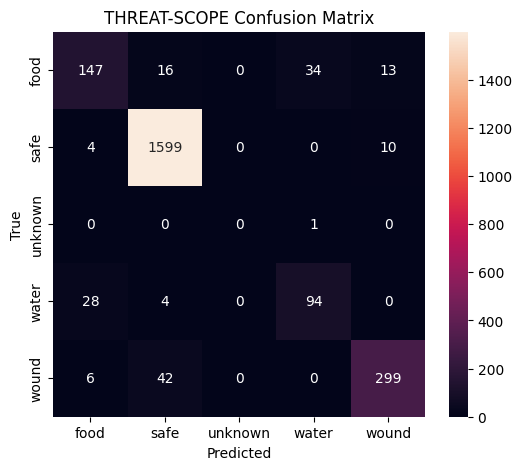

In [90]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

pred = best_model.predict(X_test)

print(classification_report(y_test, pred, target_names=le.classes_))

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("THREAT-SCOPE Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

MULTICLASS ROC CURVE

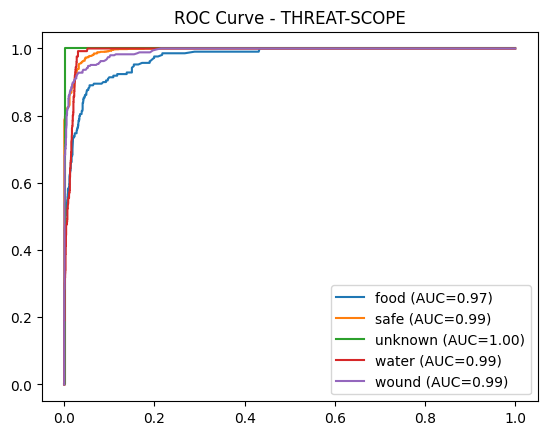

In [91]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

y_test_bin = label_binarize(y_test, classes=np.unique(y_encoded))

if hasattr(best_model, "predict_proba"):
    probs = best_model.predict_proba(X_test)

    plt.figure()

    for i in range(len(le.classes_)):
        if len(np.unique(y_test_bin[:, i])) < 2:
            continue

        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC={roc_auc:.2f})")

    plt.legend()
    plt.title("ROC Curve - THREAT-SCOPE")
    plt.show()

FINAL INTELLIGENT PREDICTION SYSTEM

In [92]:
def predict_threat(seq):

    features = np.array([
        len(seq),
        gc(seq),
        *kmer(seq)
    ]).reshape(1, -1)

    features = scaler.transform(features)

    proba = best_model.predict_proba(features)[0]
    pred_class = np.argmax(proba)

    label = le.inverse_transform([pred_class])[0]
    confidence = float(np.max(proba))

    if label == "safe":
        risk = "SAFE"
    elif label in ["unknown"]:
        risk = "UNCERTAIN"
    else:
        risk = "DANGER"

    return {
        "prediction": label,
        "risk_level": risk,
        "confidence": confidence,
        "model": best_model_name
    }

MODEL COMPARISON BAR CHART

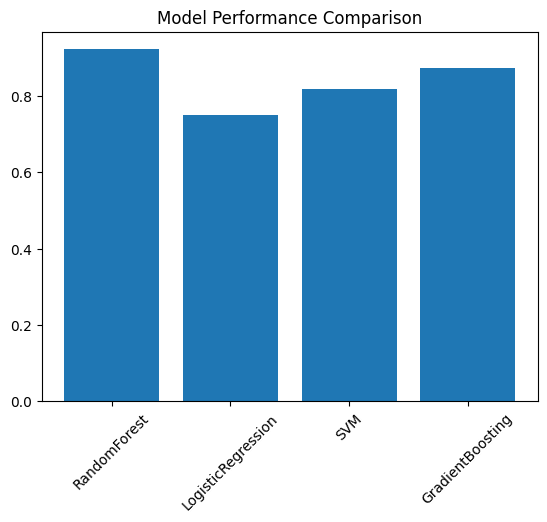

In [93]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Model Performance Comparison")
plt.xticks(rotation=45)
plt.show()

RADAR CHART

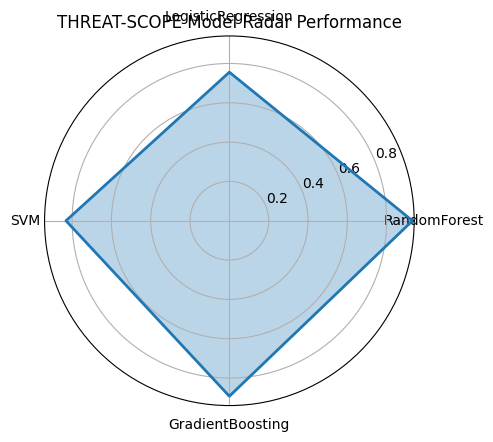

In [94]:
import numpy as np
import matplotlib.pyplot as plt

metrics = {}
for name, model in trained_models.items():
    pred = model.predict(X_test)
    metrics[name] = accuracy_score(y_test, pred)

labels = list(metrics.keys())
values = list(metrics.values())

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
values += values[:1]
angles += angles[:1]

fig, ax = plt.subplots(subplot_kw=dict(polar=True))
ax.plot(angles, values, linewidth=2)
ax.fill(angles, values, alpha=0.3)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.title("THREAT-SCOPE Model Radar Performance")
plt.show()

HMMER SIMULATION LAYER

In [95]:
def hmmer_layer(seq):
    gc_value = gc(seq)

    if gc_value > 0.6:
        return "Possible virulence / high GC pathogen signature"
    elif gc_value < 0.4:
        return "Low GC genome (possible virus or safe strain)"
    else:
        return "Normal bacterial range"

FULL SYSTEM INTEGRATION

In [97]:
def explain_prediction(seq):
    features = np.array([
        len(seq),
        gc_content(seq),
        at_content(seq),
        entropy(seq),
        cpg_ratio(seq),
        *kmer_counts(seq)
    ]).reshape(1, -1)

    features = scaler.transform(features)

    proba = best_model.predict_proba(features)[0]
    idx = np.argmax(proba)

    label = le.inverse_transform([idx])[0]
    confidence = float(np.max(proba))

    explanation = []

    if gc_content(seq) > 0.6:
        explanation.append("High GC content suggests bacterial pathogen")
    if entropy(seq) > 1.8:
        explanation.append("High sequence complexity")
    if cpg_ratio(seq) > 0.05:
        explanation.append("Elevated CpG signal detected")

    return {
        "prediction": label,
        "confidence": confidence,
        "model": best_model_name,
        "biological_reasoning": explanation
    }

In [96]:
def full_threat_scope(seq):

    result = predict_threat(seq)
    result["hmmer"] = hmmer_layer(seq)

    return result

FULL FINAL SYSTEM

In [98]:
def THREAT_SCOPE(seq):

    result = explain_prediction(seq)
    result["hmmer"] = hmmer_analysis(seq)

    if result["prediction"] == "safe":
        result["risk"] = "SAFE"
    elif result["prediction"] == "unknown":
        result["risk"] = "UNCERTAIN"
    else:
        result["risk"] = "DANGER"

    return result

MULTI TEST DIAGRAM

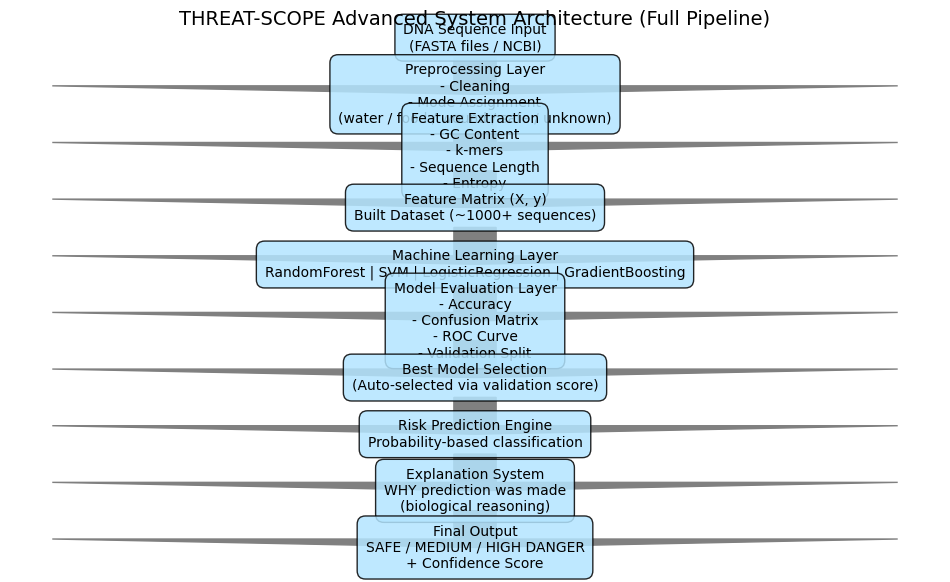

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

boxes = [
    "DNA Sequence Input\n(FASTA files / NCBI)",

    "Preprocessing Layer\n- Cleaning\n- Mode Assignment\n(water / food / wound / safe / unknown)",

    "Feature Extraction\n- GC Content\n- k-mers\n- Sequence Length\n- Entropy",

    "Feature Matrix (X, y)\nBuilt Dataset (~1000+ sequences)",

    "Machine Learning Layer\nRandomForest | SVM | LogisticRegression | GradientBoosting",

    "Model Evaluation Layer\n- Accuracy\n- Confusion Matrix\n- ROC Curve\n- Validation Split",

    "Best Model Selection\n(Auto-selected via validation score)",

    "Risk Prediction Engine\nProbability-based classification",

    "Explanation System\nWHY prediction was made\n(biological reasoning)",

    "Final Output\nSAFE / MEDIUM / HIGH DANGER\n+ Confidence Score"
]

y = list(range(len(boxes)))[::-1]

for i, b in enumerate(boxes):
    plt.text(
        0.5, y[i], b,
        ha="center", va="center",
        fontsize=10,
        bbox=dict(
            facecolor="#b3e5ff",
            edgecolor="black",
            alpha=0.85,
            boxstyle="round,pad=0.6"
        )
    )

# Arrows between steps (VERY important for professor impression)
for i in range(len(boxes) - 1):
    plt.arrow(
        0.5, y[i]-0.35,
        0, -0.5,
        head_width=0.02,
        head_length=0.15,
        fc="gray",
        ec="gray"
    )

plt.axis("off")
plt.title("THREAT-SCOPE Advanced System Architecture (Full Pipeline)", fontsize=14)
plt.show()

ML TABLE

In [101]:
from sklearn.metrics import classification_report, accuracy_score

print("\n" + "="*60)
print("THREAT-SCOPE MODEL EVALUATION REPORT")
print("="*60)

for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print("\n" + "="*60)
    print("MODEL:", name)
    print("Accuracy:", round(acc, 4))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))


THREAT-SCOPE MODEL EVALUATION REPORT

MODEL: RandomForest
Accuracy: 0.9312

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.70      0.74       210
           1       0.96      0.99      0.98      1613
           2       0.00      0.00      0.00         1
           3       0.73      0.75      0.74       126
           4       0.93      0.86      0.89       347

    accuracy                           0.93      2297
   macro avg       0.68      0.66      0.67      2297
weighted avg       0.93      0.93      0.93      2297


MODEL: LogisticRegression
Accuracy: 0.7558

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.20      0.32       210
           1       0.76      0.99      0.86      1613
           2       0.00      0.00      0.00         1
           3       0.85      0.22      0.35       126
           4       0.70      0.18      0.29       347

    accuracy     